[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/rl-basics/blob/main/Section_3_value_iteration_frozenlake.ipynb)

<div style="text-align:center">
    <h1>
        Value Iteration
    </h1>
</div>
<br>

<div style="text-align:center">
    <p>
        In this notebook we are going to look at a dynamic programming algorithm called value iteration. In it, we will sweep the state space and update all the V(s) values. We solve Frozen Lake twice: first on firm ice, then &mdash; with the exact same function &mdash; on slippery ice.
    </p>
</div>

In [1]:
# Setup: install Gymnasium. No separate envs.py is needed here, because
# Frozen Lake is built into the library.
%pip install -qq gymnasium==1.3.0 pygame

Note: you may need to restart the kernel to use updated packages.


## Import the necessary software libraries:

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Initialize the environment

We start with **firm ice** (`is_slippery=False`), exactly like the deterministic maze. The stochastic version comes at the end.

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
env.reset(seed=42)

(0, {'prob': 1})

C:\Anaconda\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


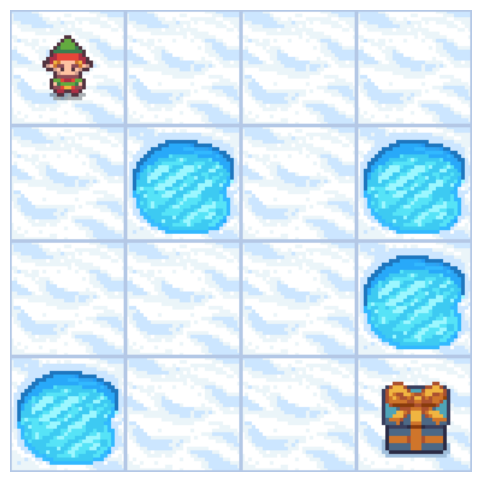

In [4]:
frame = env.render()
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(frame)

In [5]:
print(f"Observation space: {env.observation_space}")   # 16 tiles, numbered 0..15
print(f"Number of actions: {env.action_space.n}")       # 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP

Observation space: Discrete(16)
Number of actions: 4


#### Visualization helpers

In the maze notebooks these lived in `utils.py`. Here we define Frozen Lake versions inline, so the notebook is self-contained. Nothing below is part of the algorithm &mdash; it only draws pictures. Feel free to run the cell and move on.

In [6]:
import matplotlib
from matplotlib import animation
from IPython.display import HTML

# The lake layout as characters: S(start), F(frozen), H(hole), G(gift).
# We use it to know which tiles are terminal, so we don't draw arrows/values on them.
DESC = np.array([list(row.decode()) for row in env.unwrapped.desc.flatten()]).reshape(4, 4)


def plot_values(state_values, title="State values V(s)"):
    """Draw the 16 state values as an annotated 4x4 heatmap. Holes are marked H, the gift G."""
    grid = state_values.reshape(4, 4)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap="Purples", vmin=0, vmax=max(grid.max(), 1e-9))
    for r in range(4):
        for c in range(4):
            cell = DESC[r, c]
            label = cell if cell in "HG" else f"{grid[r, c]:.2f}"
            # White text on dark (high-value) cells, black on light ones.
            color = "white" if grid[r, c] > 0.6 * max(grid.max(), 1e-9) else "black"
            plt.text(c, r, label, ha="center", va="center", color=color, fontsize=12)
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.show()


def plot_policy(policy_probs, title="Policy"):
    """Draw the greedy action in each tile as an arrow. Terminal tiles get their letter instead."""
    # Arrow directions in plot coordinates for actions 0..3 = LEFT, DOWN, RIGHT, UP.
    # (dy is positive-down because row numbers grow downward in the image.)
    arrows = {0: (-0.3, 0), 1: (0, 0.3), 2: (0.3, 0), 3: (0, -0.3)}
    plt.figure(figsize=(5, 5))
    plt.imshow(np.zeros((4, 4)), cmap="Purples", vmin=0, vmax=1)
    for s in range(16):
        r, c = divmod(s, 4)
        if DESC[r, c] in "HG":
            plt.text(c, r, DESC[r, c], ha="center", va="center", fontsize=16)
            continue
        a = int(np.argmax(policy_probs[s]))
        dx, dy = arrows[a]
        plt.arrow(c, r, dx, dy, head_width=0.12, head_length=0.1, fc="black", ec="black")
    plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.show()


def display_video(frames):
    """Turn a list of rendered frames into an HTML5 video the notebook plays inline."""
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')                      # build frames without opening a window
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    matplotlib.use(orig_backend)
    ax.set_axis_off(); ax.set_aspect('equal'); ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
        im.set_data(frame)
        return [im]
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=250, blit=True, repeat=False)
    return HTML(anim.to_html5_video())


def test_agent(environment, policy, episodes=1):
    """Run the policy for some episodes and return a video of the attempt(s)."""
    frames = []
    for _ in range(episodes):
        state, info = environment.reset()
        done = False
        frames.append(environment.render())
        while not done:
            action = np.random.choice(4, p=policy(state))
            state, reward, terminated, truncated, _ = environment.step(action)
            done = terminated or truncated
            frames.append(environment.render())
    return display_video(frames)

## Define the policy $\pi(\cdot|s)$

#### Create the policy $\pi(\cdot|s)$

The policy table stores, for every state, the probability of choosing each action. In the maze the table had shape (5, 5, 4) because states were (row, col) pairs; in Frozen Lake states are single integers 0&ndash;15, so the table is simply **(16, 4)**. We start uniform: every action equally likely everywhere.

In [7]:
policy_probs = np.full((16, 4), 0.25)

In [8]:
def policy(state):
    return policy_probs[state]

#### Test the policy with state 0

In [9]:
action_probabilities = policy(0)
for action, prob in zip(range(4), action_probabilities):
    print(f"Probability of taking action {action}: {prob}")

Probability of taking action 0: 0.25
Probability of taking action 1: 0.25
Probability of taking action 2: 0.25
Probability of taking action 3: 0.25


#### See how the random policy does on the lake

In [10]:
# One episode of the untrained (random) policy - it usually ends in a hole quickly.
test_agent(env, policy, episodes=1)

#### Plot the policy

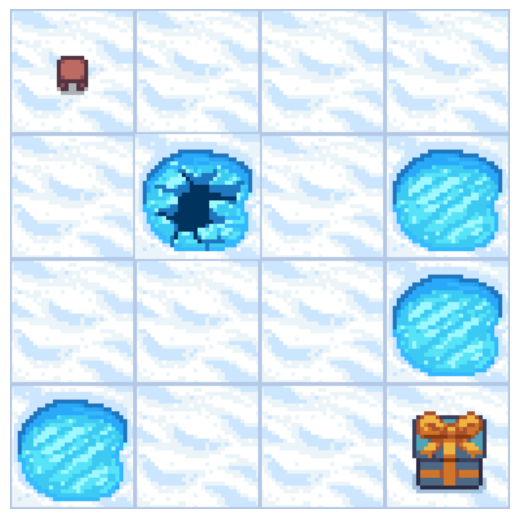

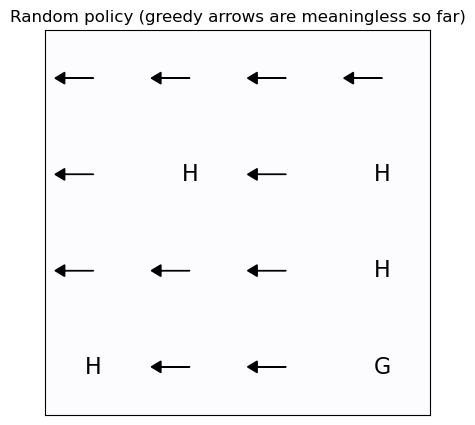

In [11]:
plot_policy(policy_probs, title="Random policy (greedy arrows are meaningless so far)")

## Define value table $V(s)$

#### Create the $V(s)$ table

One number per tile, estimating how good it is to stand there (the expected total future reward). In this lake, since the only reward is +1 at the gift, $V(s)$ has a very concrete reading: *the discounted probability-weighted chance of eventually reaching the gift from tile s, if we act well.* We start every tile at 0.

In [12]:
state_values = np.zeros(16)

#### Plot V(s)

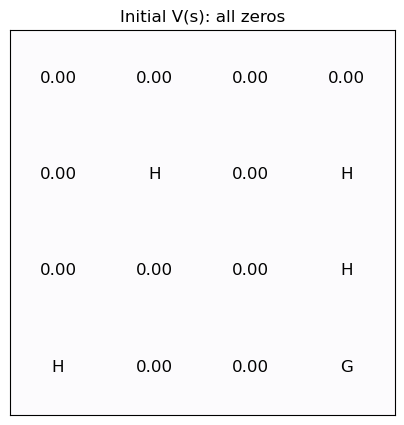

In [13]:
plot_values(state_values, title="Initial V(s): all zeros")

## Implement the Value Iteration algorithm

**The big idea (in plain language).**
Value iteration is a shortcut. Instead of fully evaluating a policy and then improving it
(as policy iteration does), it folds both steps into one. In every sweep over the tiles we set
each state's value to the value of its *best* action, not the average over actions.

**What changes compared to the maze &mdash; and this is the important part.**
In the deterministic maze, one action led to exactly one outcome, so we could score an action with a single simulated step:

$$Q(s, a) = r + \gamma \, V(s')$$

On a lake that may be slippery, one action can lead to *several* outcomes, each with its own probability. The score of an action must therefore be an **expectation** &mdash; a probability-weighted average over everything that could happen:

$$Q(s, a) = \sum_{s'} p(s', r \mid s, a)\,\bigl[\, r + \gamma \, V(s') \,\bigr]$$

Note that the deterministic formula is just the special case where one outcome has probability 1. By writing the general form once, **the same function will solve both the firm and the slippery lake** &mdash; we will verify this at the end.

**Where do the probabilities come from?** Frozen Lake exposes its full transition model as `env.unwrapped.P`. For each state `s` and action `a`, `P[s][a]` is a list of possible outcomes, each a tuple:

```
(probability, next_state, reward, terminated)
```

Dynamic programming methods are exactly the methods that are allowed to read this table. (Later lessons remove that privilege: Monte Carlo and TD methods must learn from experienced transitions only.)

**One subtlety: terminal states.** Holes and the gift are absorbing: their entries in `P` loop back to themselves with reward 0. Because we initialize $V = 0$ everywhere, their values remain 0 through every sweep &mdash; which is correct, since no future reward is collectable once the episode has ended. The +1 for the gift is earned on the transition *into* tile 15, so it lives in the `P` entries of the neighboring tiles.

**The algorithm.** For each state we:
1. compute `Q(s, a)` for all 4 actions using the expectation above;
2. keep the largest `Q` and store it as the state's new value (the Bellman **optimality** update);
3. remember which action was best &mdash; that becomes the policy for this state.

We keep sweeping until no value changes by more than a tiny threshold `theta`, at which point both the values and the greedy policy they imply are optimal.

</br>

<div style="text-align:center">
    Adapted from Barto & Sutton: "Reinforcement Learning: An Introduction".
</div>

In [14]:
def value_iteration(env, policy_probs, state_values, theta=1e-6, gamma=0.99):
    # The full transition model: P[s][a] = list of (probability, next_state, reward, terminated).
    P = env.unwrapped.P
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    delta = float('inf')
    while delta > theta:               # sweep until no value moves more than theta
        delta = 0
        for state in range(n_states):
            old_value = state_values[state]

            # Score every action with the EXPECTED Bellman backup:
            # Q(s,a) = sum over outcomes of p * (r + gamma * V(s')).
            # This one line is what makes the function work on slippery ice too.
            qsa = [
                sum(p * (r + gamma * state_values[s_next])
                    for p, s_next, r, terminated in P[state][action])
                for action in range(n_actions)
            ]

            best_action = int(np.argmax(qsa))

            # Bellman optimality update: the state is worth its best action.
            state_values[state] = qsa[best_action]

            # The greedy policy: put all probability on the best action.
            policy_probs[state] = np.zeros(n_actions)
            policy_probs[state][best_action] = 1.0

            delta = max(delta, abs(state_values[state] - old_value))

In [15]:
value_iteration(env, policy_probs, state_values)

## Show results

#### Show resulting value table $V(s)$

Read the heatmap from the gift outward: the tile just before the gift is worth about $\gamma = 0.99$, the one before that about $\gamma^2$, and so on. Each step away from the gift multiplies the value by $\gamma$ &mdash; the discount visibly propagating backward through the lake.

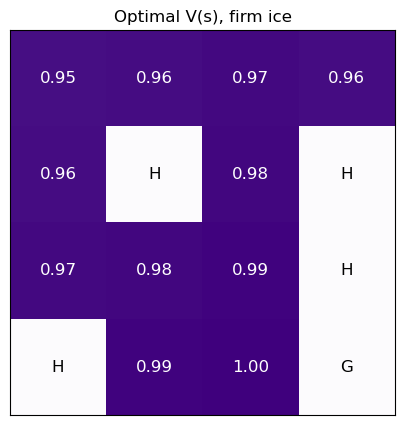

In [16]:
plot_values(state_values, title="Optimal V(s), firm ice")

#### Show resulting policy $\pi(\cdot|s)$

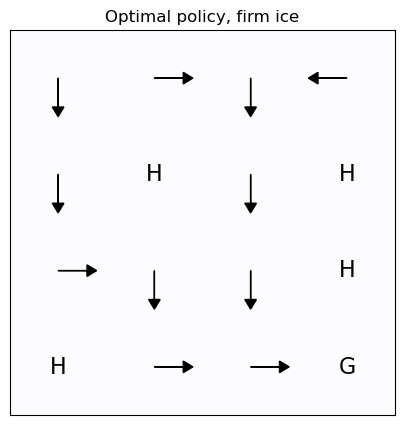

In [17]:
plot_policy(policy_probs, title="Optimal policy, firm ice")

#### Test the resulting agent

In [18]:
test_agent(env, policy, episodes=1)

## The payoff: the same algorithm on slippery ice

In the RL-basics notebook we saw that a memorized plan, perfect on firm ice, collapsed to under 1% success on slippery ice. Now we can do better. Because our `value_iteration` uses the *expected* Bellman backup, we can hand it the slippery lake **without changing a single line**: the expectation simply now runs over three outcomes per action (probability 1/3 each) instead of one.

In [19]:
env_slippery = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
env_slippery.reset(seed=42)

# Fresh tables, same algorithm.
policy_probs_slip = np.full((16, 4), 0.25)
state_values_slip = np.zeros(16)

value_iteration(env_slippery, policy_probs_slip, state_values_slip)

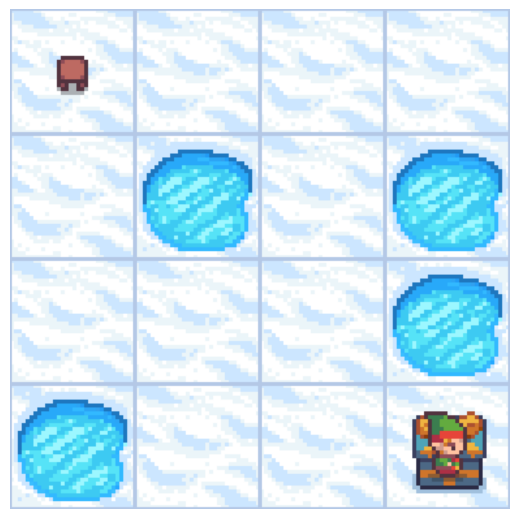

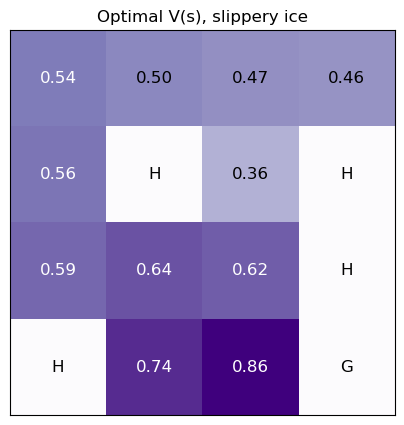

In [20]:
plot_values(state_values_slip, title="Optimal V(s), slippery ice")

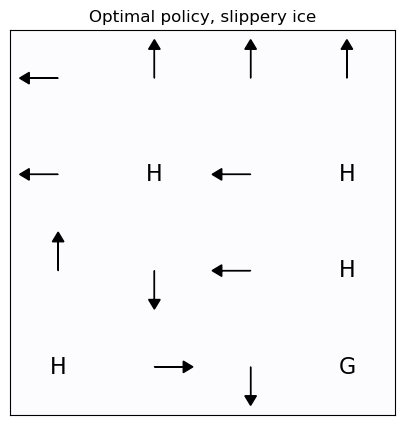

In [21]:
plot_policy(policy_probs_slip, title="Optimal policy, slippery ice")

**Read this policy carefully &mdash; it looks wrong, and that is the lesson.** Several arrows point *away* from the gift or straight at a wall. They are not mistakes. On slippery ice, the chosen action succeeds only 1/3 of the time and slips sideways otherwise, so the optimal move in a tile next to a hole is often the one whose *worst slip* is harmless &mdash; even if its *intended* direction is unhelpful. For example, aiming at a wall can be optimal: the intended move wastes a step, but both sideways slips move you somewhere safe. The optimal policy manages risk, not just distance.

Also notice the values are much lower than on firm ice: even acting optimally, success is no longer guaranteed. Let us measure exactly how much better optimal play is than the alternatives:

In [22]:
def success_rate(environment, policy_fn, episodes=1000):
    wins = 0
    for _ in range(episodes):
        state, info = environment.reset()
        done = False
        while not done:
            action = np.random.choice(4, p=policy_fn(state))
            state, reward, terminated, truncated, _ = environment.step(action)
            done = terminated or truncated
        wins += reward   # last reward is 1 only if the gift was reached
    return wins / episodes


random_probs = np.full((16, 4), 0.25)
print(f"Random policy on slippery ice:          {success_rate(env_slippery, lambda s: random_probs[s]):.1%}")
print(f"Value-iteration policy on slippery ice: {success_rate(env_slippery, lambda s: policy_probs_slip[s]):.1%}")
print("(Recall from the previous notebook: the fixed firm-ice plan scored ~1% here.)")

Random policy on slippery ice:          1.7%
Value-iteration policy on slippery ice: 73.7%
(Recall from the previous notebook: the fixed firm-ice plan scored ~1% here.)


In [23]:
test_agent(env_slippery, lambda s: policy_probs_slip[s], episodes=1)

In [24]:
env.close()
env_slippery.close()

## Summary

| | Firm ice | Slippery ice |
|---|---|---|
| Transitions | deterministic, $p(s' \mid s,a)=1$ | stochastic, three outcomes at 1/3 each |
| Bellman backup needed | $r + \gamma V(s')$ (special case) | $\sum_{s'} p\,(r + \gamma V(s'))$ (general form) |
| Optimal V(s) | $\gamma^{\text{steps to gift}}$, near 1 | much lower: risk is unavoidable |
| Optimal policy | arrows trace the shortest path | arrows manage risk, sometimes pointing at walls |
| Success rate of optimal play | 100% | well below 100%, but far above random |

Value iteration finds these policies because it may **read the transition model** `env.unwrapped.P`. That is a strong assumption: in most real problems no such table exists. The next lessons remove it &mdash; Monte Carlo and temporal-difference methods reach the same destination using nothing but experienced transitions.

## Resources

[[1] Reinforcement Learning: An Introduction. Ch. 4: Dynamic Programming](https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf)